# Exploratory Data analysis

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
try:
    df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')  # Kaggle
except FileNotFoundError:
    try:
        df = pd.read_csv('/content/drive/MyDrive/Data sets/credit card ml project/creditcard.csv')    # Google Drive (Colab)
    except FileNotFoundError:
        df = pd.read_csv("E:/AI ML/Project/Data/creditcard.csv")                           # Local

### Basic Checks

In [38]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [39]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [41]:
df.shape

(284807, 31)

In [42]:
df.duplicated().sum()

np.int64(1081)

In [43]:
df = df.drop_duplicates()

In [44]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


### Exploratory Data analysis

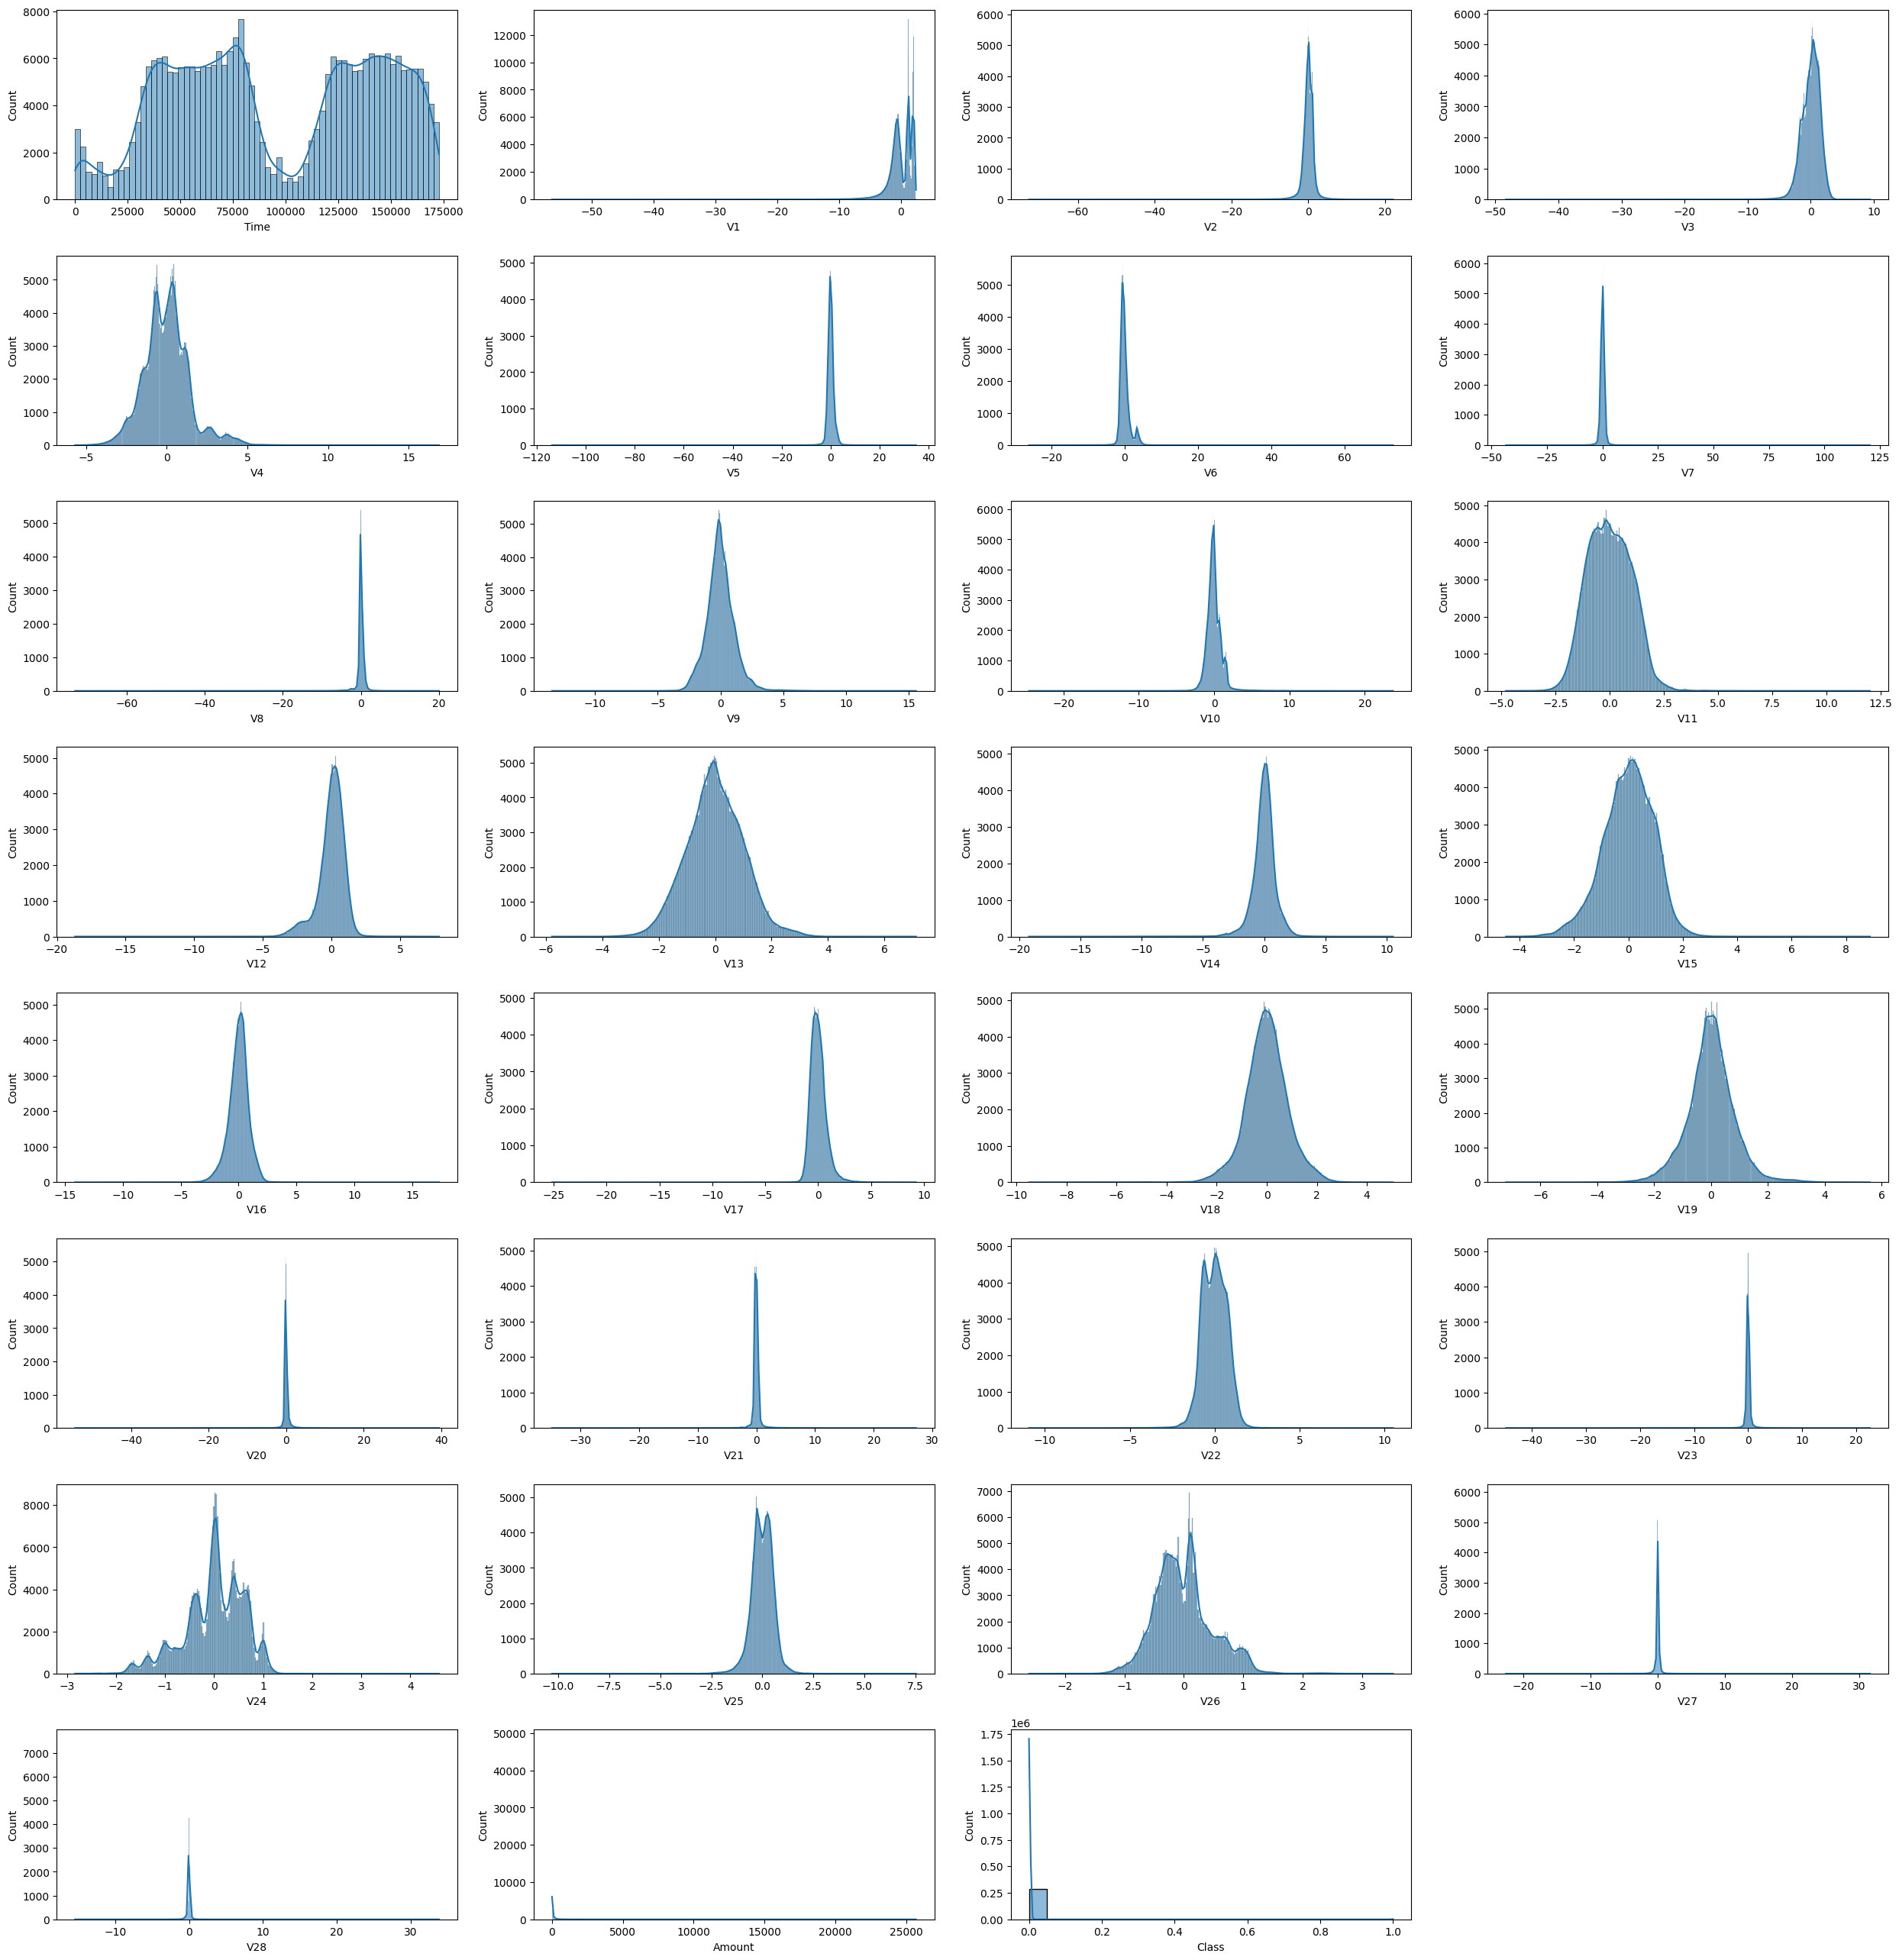

In [ ]:
n = 1
plt.figure(figsize=(25,35))
for i in df.columns:
    if n <= len(df.columns):
        ax = plt.subplot(11, 4, n)
        sns.histplot(x=df[i], kde=True)
        plt.xlabel(i)
    n += 1
plt.tight_layout()
plt.show()

In [ ]:
df['Class'].value_counts()

,count
Class,
0,283253
1,473


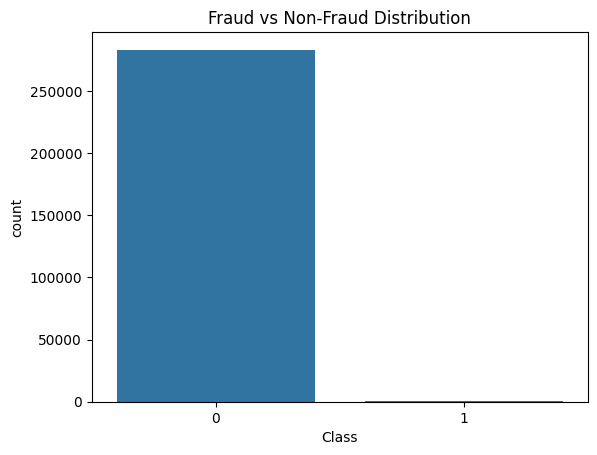

In [ ]:
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

### Our Data is highly imbalanced by analysing class column.

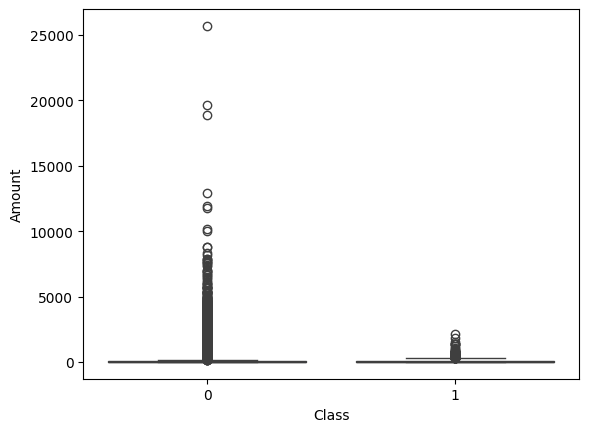

In [ ]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.show()

### Fraud has happened under 5k amount

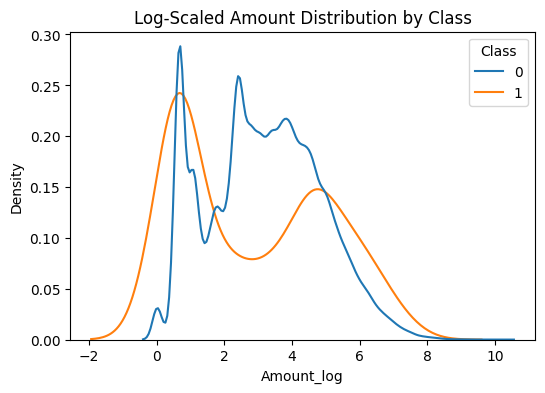

In [ ]:
df['Amount_log'] = np.log1p(df['Amount'])

plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='Amount_log', hue='Class', common_norm=False)
plt.title("Log-Scaled Amount Distribution by Class")
plt.show()

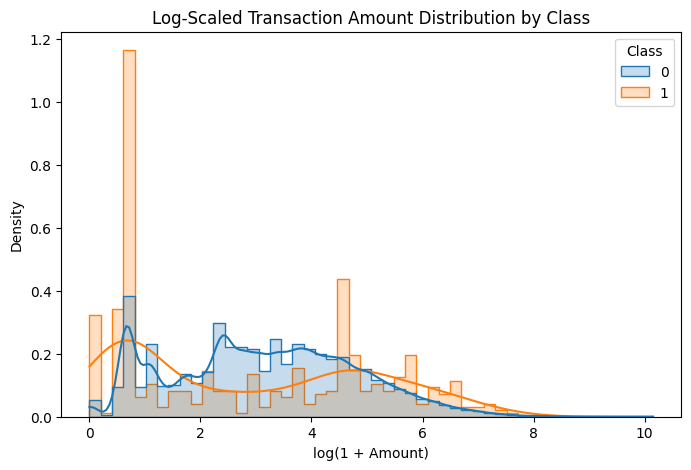

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Amount_log', hue='Class', bins=50, kde=True, element='step', stat='density', common_norm=False)
plt.title("Log-Scaled Transaction Amount Distribution by Class")
plt.xlabel("log(1 + Amount)")
plt.show()

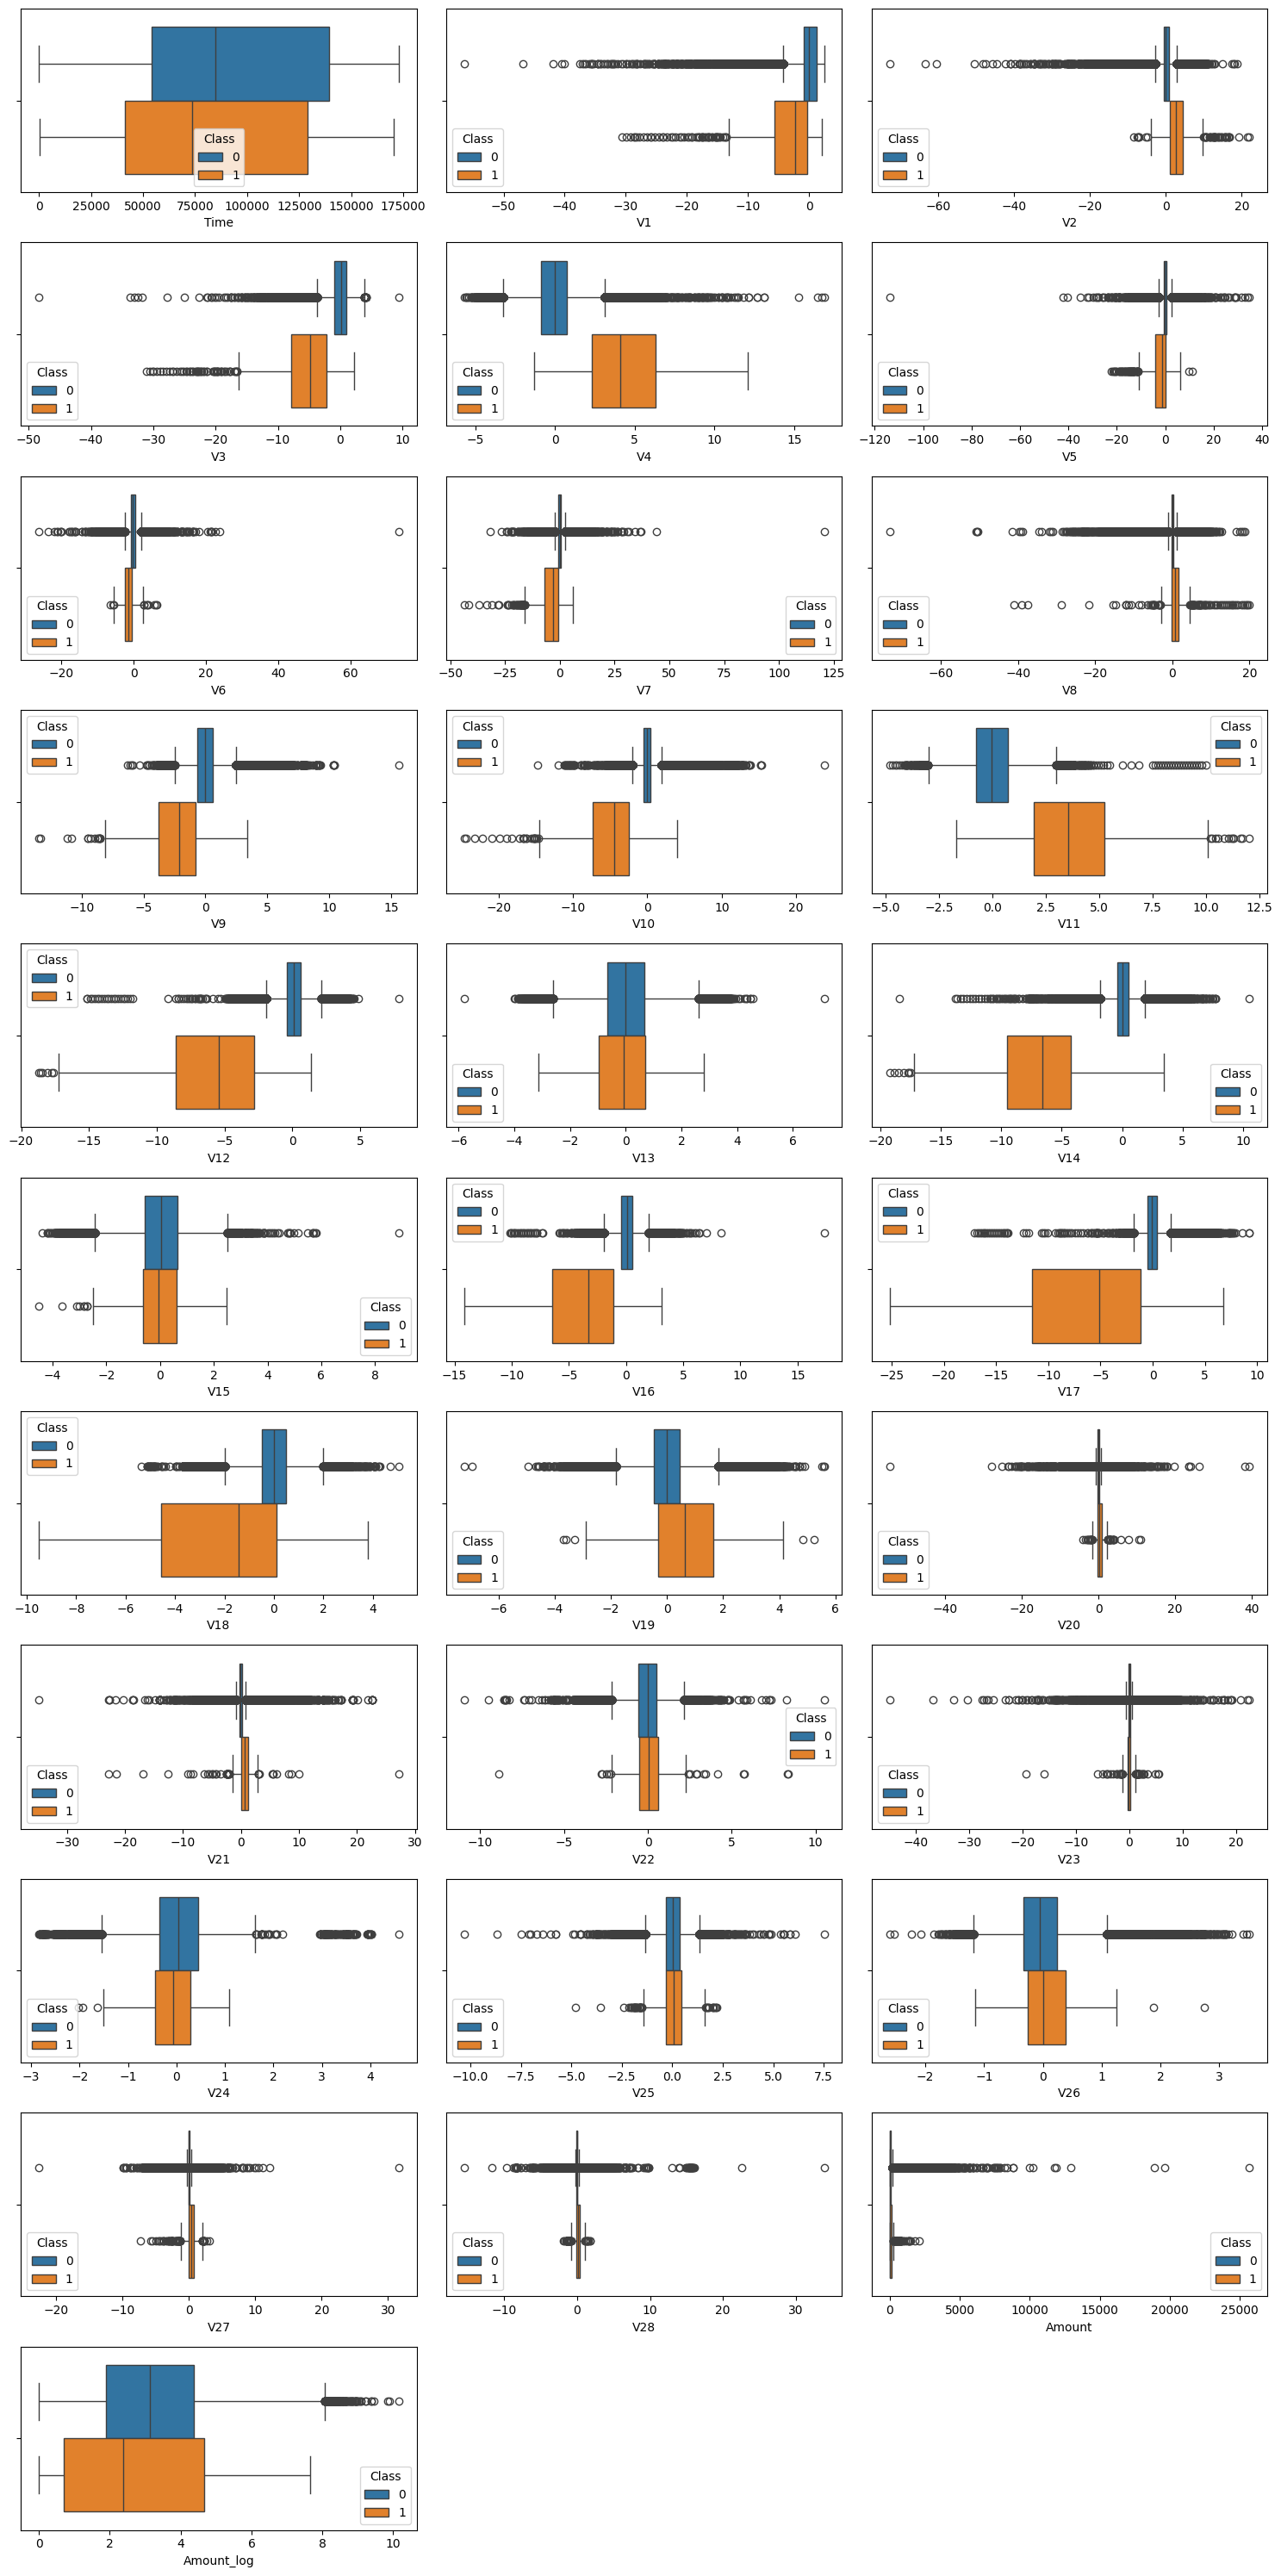

In [ ]:
n = 1
plt.figure(figsize=(15, 30))
for i in df.drop(columns='Class').columns:
    if n <= len(df.columns):
        ax = plt.subplot(11,3,n)
        sns.boxplot(data =df, x=i, hue='Class')
    n += 1

plt.tight_layout()
plt.show()

### The target variable is highly imbalanced, with fraudulent transactions forming a very small fraction of total records, and fraud has happened under amount of 5k.

## Outlier Handling: Extreme values were retained as they may represent genuine fraud behavior rather than noise.

## feature Engineering

In [ ]:
df.corr()['Class'].sort_values(ascending=False)

,Class
Class,1.000000
V11,0.149067
V4,0.129326
V2,0.084624
V19,0.033631
V8,0.033068
V21,0.026357
V27,0.021892
V20,0.021486
V28,0.009682


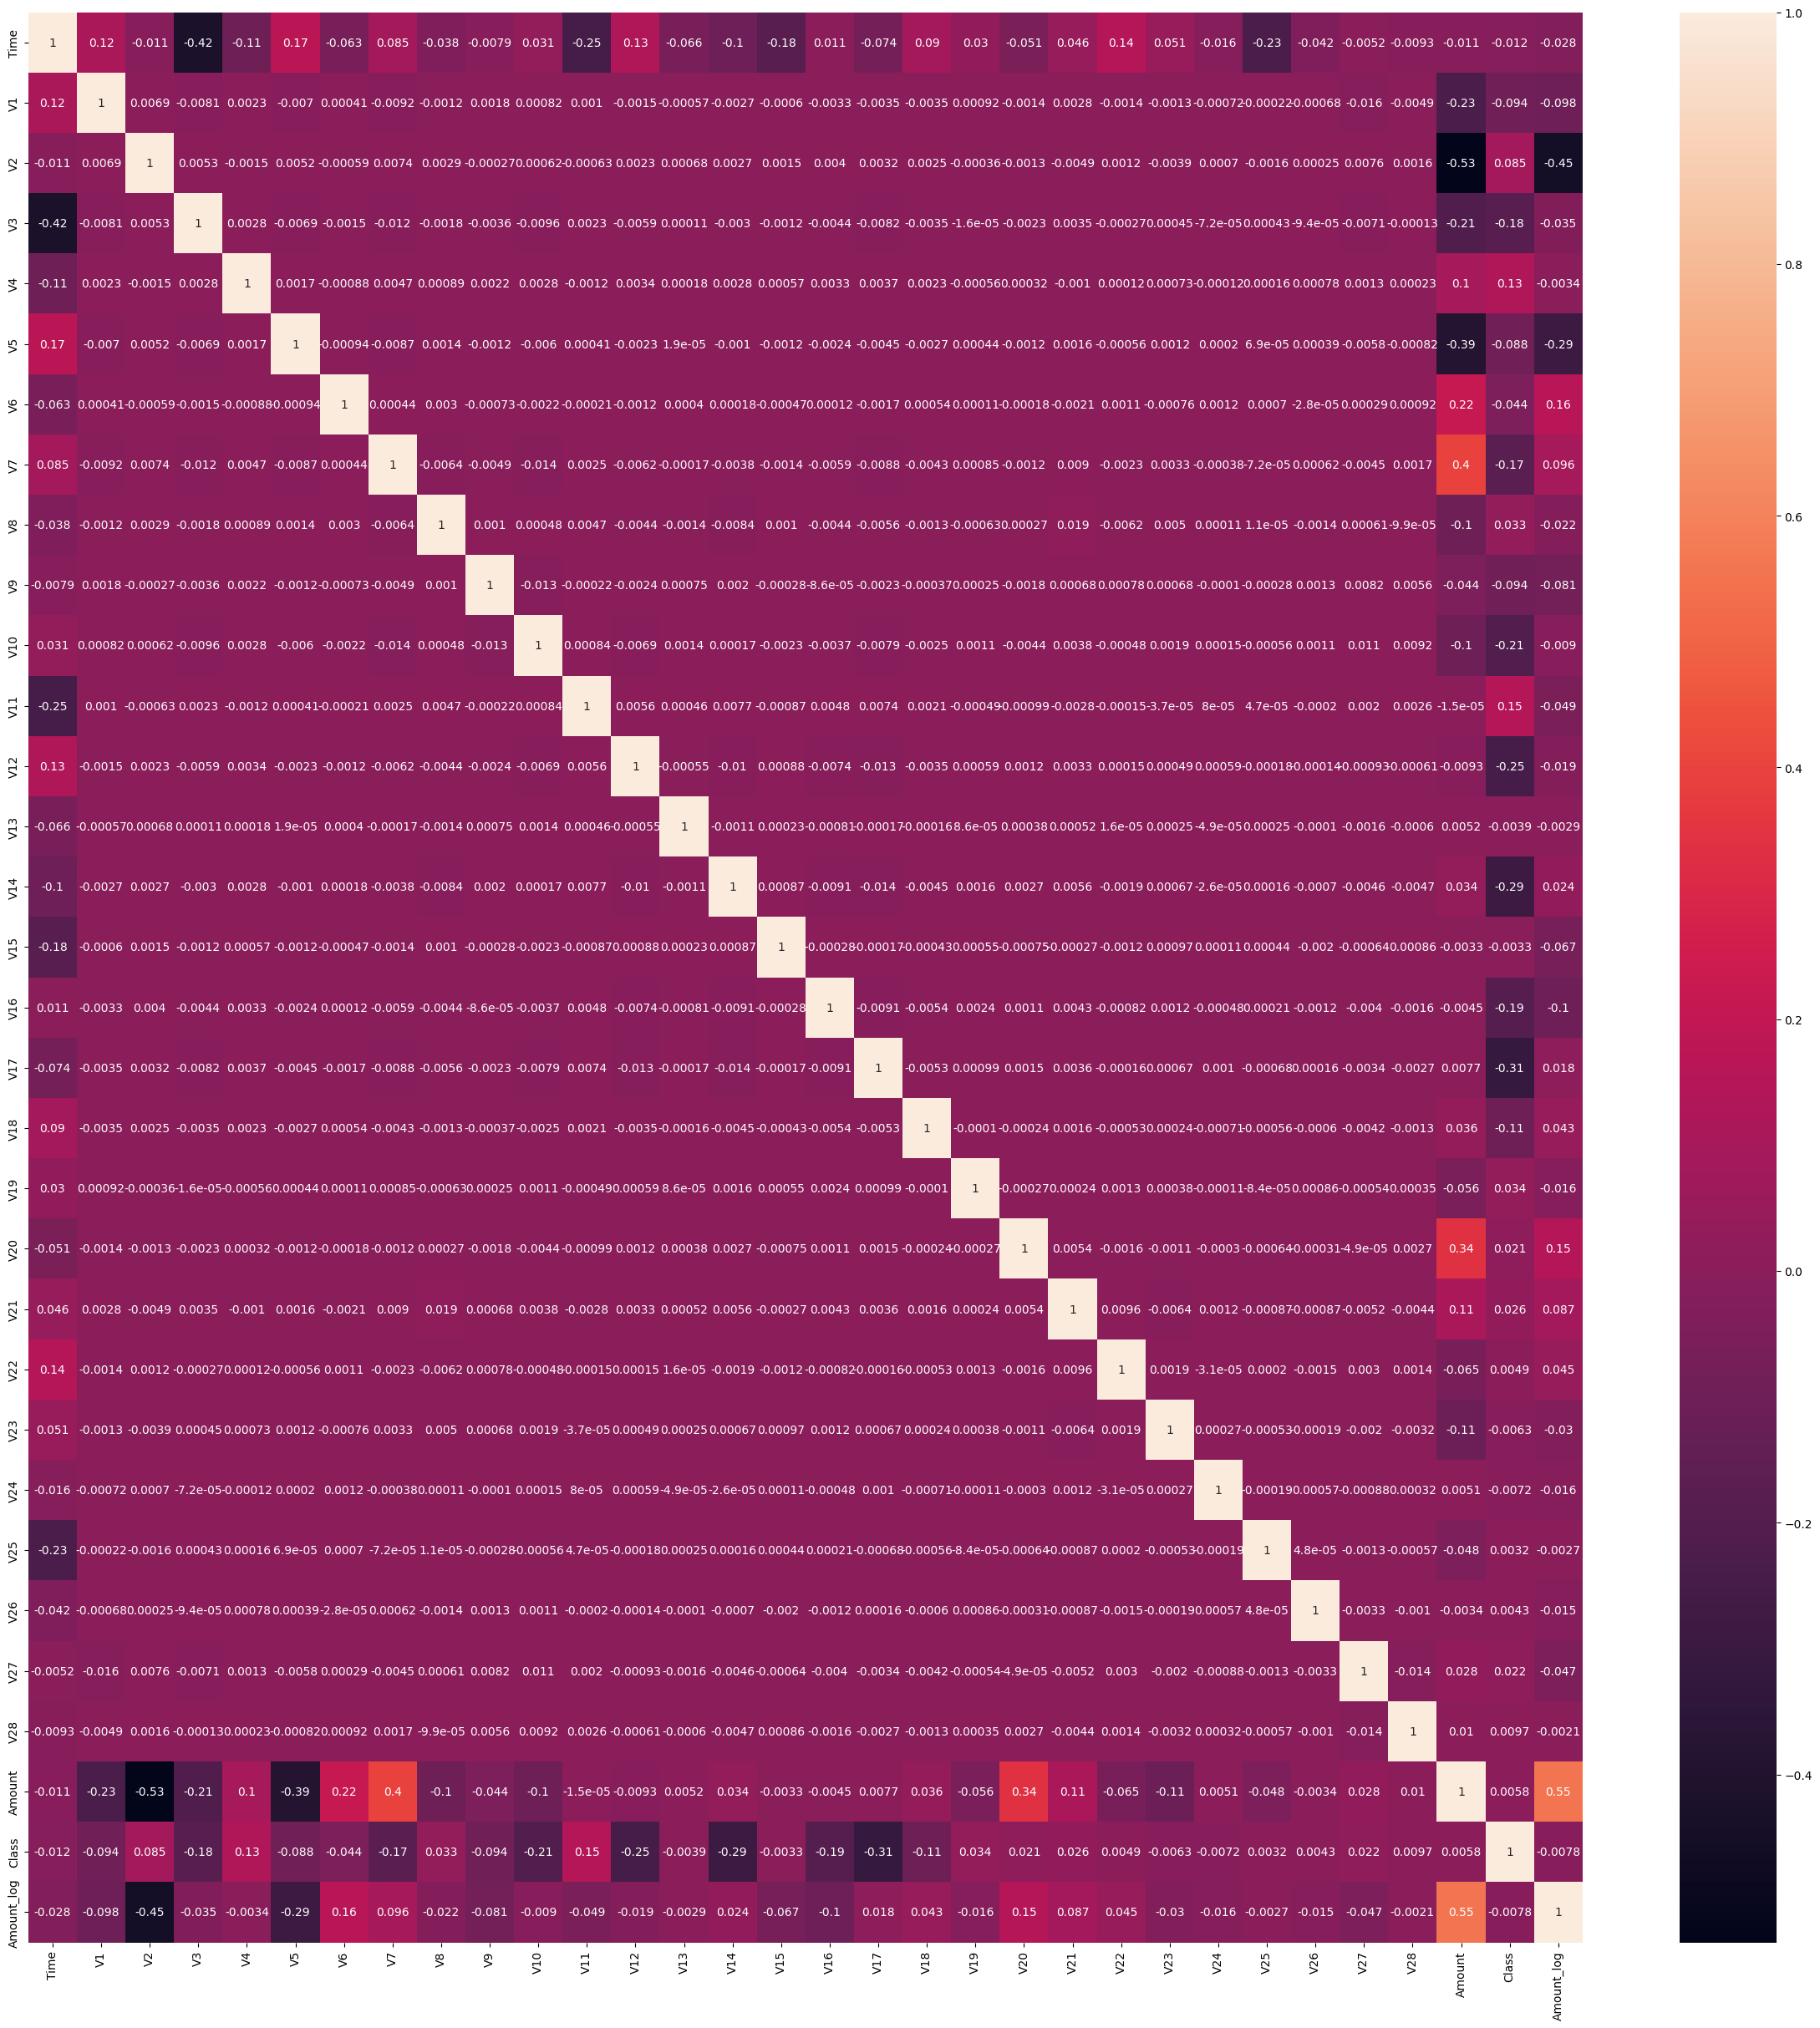

In [ ]:
plt.figure(figsize=(30,30))
sns.heatmap(df.corr(), annot=True)
plt.show()


### Feature Correlation: The correlation heatmap indicates no strong linear correlation among most input features.

In [45]:
# saving cleaned data
import os

clean_df = pd.DataFrame(df)

# Saving in local drive
try:

    os.makedirs("data", exist_ok=True)

    clean_df.to_csv("E:/AI ML/Project/Data/clean_data.csv", index=False)

    print("Saved locally in data/clean_data.csv")

except Exception as e:

    print("Local save failed:", e)

# saving in personal google drive
try:

    drive_path = "/content/drive/MyDrive/Data sets/credit card ml project/cleaned_data"

    os.makedirs(drive_path, exist_ok=True)

    clean_df.to_csv(f"{drive_path}/clean_data.csv", index=False)

    print("Saved in Google Drive!")

except Exception as e:

    print("Drive save skipped:", e)

Local save failed: Cannot save file into a non-existent directory: 'E:/AI ML/Project/Data'
Saved in Google Drive!


# Conclusion

## The dataset exhibits extreme class imbalance with fraudulent transactions forming a very small fraction of total observations.